# Introduction

In this Quiz #1 you need to perform exploratory data analysis (EDA) and preprocessing using "Census Income" dataset. The dataset is tabular data which has several missing value in some variables. Moreover, you may need to adjust the name of variables (if needed).

To guide you through this task, some code has beed provided including, download the data, loading the data, and metadata inspection.

# Load Data and Inspect Metadata

In [4]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [5]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [6]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [7]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
# Data Size
df.shape

(48842, 15)

In [30]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Part 1 - Data Loading dan Data Imputation

## Task 1 (5 points)
1.   Do inspection to get the information about dataset
2.   **Which variable(s)** has **missing values**? **How many is it**?



In [9]:
df.info()
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 9.3 MB


workclass         963
occupation        966
native-country    274
dtype: int64

Variabel yang memiliki nilai yang hilang adalah *work class* (963), *occupation* (966), dan *native-country* (274). Kumpulan data ini memuat 48.842 rekaman dan 15 variabel.

## Task 2 (5 points)
1. Perform data imputation on missing values.
2. Verified the missing values for each variable. Is it still there?

In [10]:
column = ['workclass', 'occupation', 'native-country']
for col in column:
    df[col] = df[col].fillna(df[col].mode()[0])

df[column].isnull().sum()

workclass         0
occupation        0
native-country    0
dtype: int64

In [11]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Imputasi data dilakukan pada variabel *workclass*, *occupation*, dan *native-country*. Setelah imputasi, tidak ada lagi nilai yang hilang dalam daya set teersebut

## Task 3 (10 points)
Do inspection to all the quantitative variables (features). If you found an **inappropriate value(s)**, replace it with '**Others**'. Also, if you found any typos value(s), **fix the typos**.

In [12]:
num_cols = df.select_dtypes(include=['object', 'category']).columns

for col in num_cols:
    print(f"\n{col}:")
    print(df[col].unique())


workclass:
<ArrowStringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',                '?',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

education:
<ArrowStringArray>
[   'Bachelors',      'HS-grad',         '11th',      'Masters',
          '9th', 'Some-college',   'Assoc-acdm',    'Assoc-voc',
      '7th-8th',    'Doctorate',  'Prof-school',      '5th-6th',
         '10th',      '1st-4th',    'Preschool',         '12th']
Length: 16, dtype: str

marital-status:
<ArrowStringArray>
[        'Never-married',    'Married-civ-spouse',              'Divorced',
 'Married-spouse-absent',             'Separated',     'Married-AF-spouse',
               'Widowed']
Length: 7, dtype: str

occupation:
<ArrowStringArray>
[     'Adm-clerical',   'Exec-managerial', 'Handlers-cleaners',
    'Prof-specialty',     'Other-service',             'Sales',
      'Craft-repair',  'Transport-moving',   'Farming-

C:\Users\fidelac\AppData\Local\Temp\ipykernel_25424\3430476481.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  num_cols = df.select_dtypes(include=['object', 'category']).columns


In [13]:
df = df.replace('?', 'Others')
print(df['workclass'].unique())

<ArrowStringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',           'Others',
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str


In [14]:
print(df['native-country'].unique())

<ArrowStringArray>
[             'United-States',                       'Cuba',
                    'Jamaica',                      'India',
                     'Others',                     'Mexico',
                      'South',                'Puerto-Rico',
                   'Honduras',                    'England',
                     'Canada',                    'Germany',
                       'Iran',                'Philippines',
                      'Italy',                     'Poland',
                   'Columbia',                   'Cambodia',
                   'Thailand',                    'Ecuador',
                       'Laos',                     'Taiwan',
                      'Haiti',                   'Portugal',
         'Dominican-Republic',                'El-Salvador',
                     'France',                  'Guatemala',
                      'China',                      'Japan',
                 'Yugoslavia',                       'Peru',
 'Out

In [15]:
df['native-country'] = df['native-country'].replace({
    'Columbia': 'Colombia',
    'Trinadad&Tobago': 'Trinidad&Tobago',
    'Holand-Netherlands': 'Netherlands'
})

# Part 2 - Visual Inspection



## Task 1 - Data Visualization (20 points)
Do inspection on this following variabels,
1. On the 'age' by using a histogram
2. On the 'education' using a barchart
3. On the 'income' to 'hours_per_week' by using a boxplot (grouped by income)
4. On the 'age' to 'capital-gain' and 'capital-loss' using lineplot (lineplot with multiple x-data)

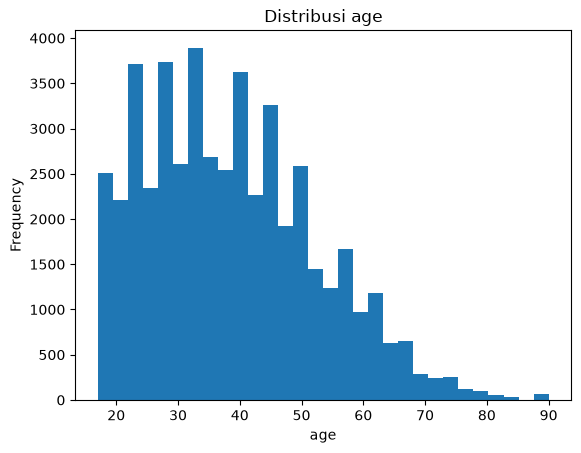

In [16]:
num_cols = ['age']
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f'Distribusi {col}')
    plt.xlabel(col); plt.ylabel('Frequency')
    plt.show()

<Axes: xlabel='count', ylabel='education'>

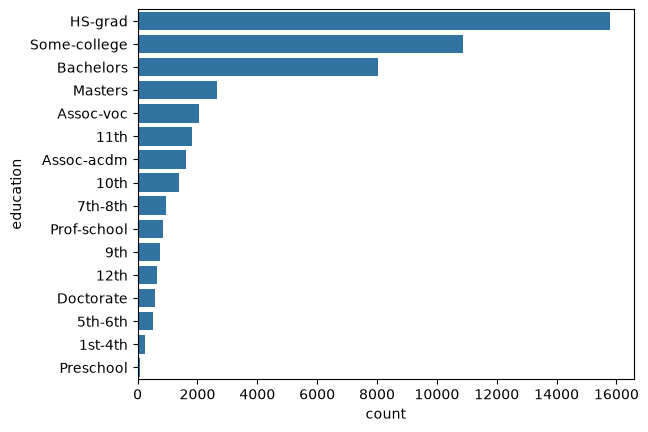

In [17]:
sns.countplot(data=df, y='education', order=df['education'].value_counts().index)

<Axes: xlabel='income', ylabel='hours-per-week'>

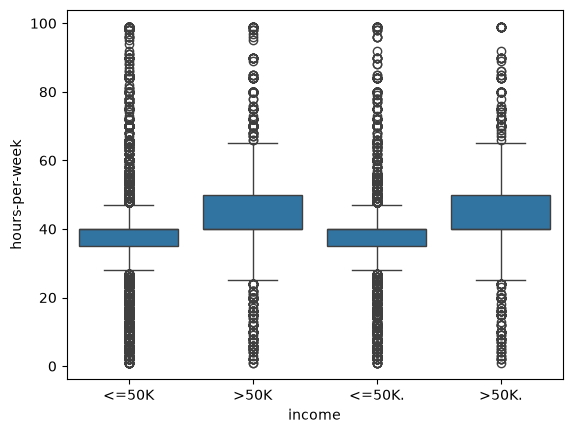

In [18]:
sns.boxplot(data=df, x='income', y='hours-per-week')

<Axes: xlabel='age', ylabel='capital-gain'>

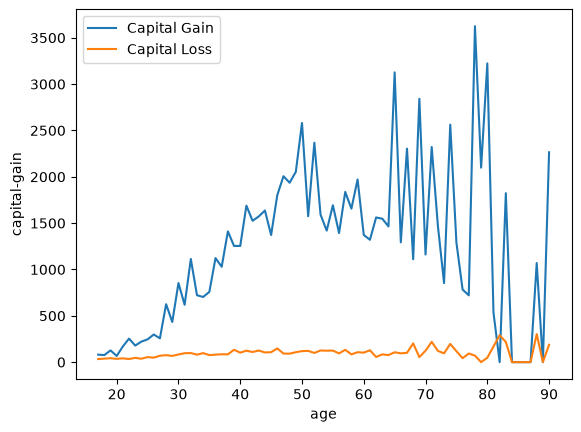

In [19]:
age_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean().reset_index()

sns.lineplot(data=age_capital, x='age', y='capital-gain', label='Capital Gain')
sns.lineplot(data=age_capital, x='age', y='capital-loss', label='Capital Loss')

## Task 2 - Visual Analysis (15 points)
1. What kind of distribution showed in 'age'?
2. If you find missing values in 'age', what kind of data impute method will you use? Why?
3. How many outliner for each category (group) in 'income' related to 'hour-per-week'? Which category has more outlier?

In [63]:

'''
1. The age distribution is right-skewed (positively skewed), because most observations are concentrated at younger and middle ages, with a tail extending toward older ages.
2. use median imputation because age is a numerical variable and its distribution is skewed. The median is less affected by extreme values than the mean.x
3. The <=50K category has more outliers.
'''

'\n1. The age distribution is right-skewed (positively skewed), because most observations are concentrated at younger and middle ages, with a tail extending toward older ages.\n2. use median imputation because age is a numerical variable and its distribution is skewed. The median is less affected by extreme values than the mean.x\n3. The <=50K category has more outliers.\n'

# Part 3 - Encoding in Categorical Variable

## Task 1 (5 points)
Do encoding process on 'Sex' and 'Income', while 'Income' is target variable.

In [20]:
print(df['sex'].unique())
print(df['income'].unique())

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
<ArrowStringArray>
['<=50K', '>50K', '<=50K.', '>50K.']
Length: 4, dtype: str


In [21]:
df['sex'] = df['sex'].map({'Male': 1,'Female': 0})
df['income'] = df['income'].map({'<=50K': 0,'>50K': 1})

In [22]:
print(df[['sex', 'income']].head())

   sex  income
0    1     0.0
1    1     0.0
2    1     0.0
3    1     0.0
4    0     0.0


# Part 4 - Correlation Analysis

## Task 1 (10 points)
1. Do correlation analysis on the following variabels: 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', and 'income' (encoded version from previous task)
2. Based on the result, what kind of information you get?

In [23]:
corr_cols = ['age','education-num','hours-per-week','capital-gain','capital-loss','income']
corr = df[corr_cols].corr()
print(corr)

                     age  education-num  hours-per-week  capital-gain  \
age             1.000000       0.030940        0.071558      0.077229   
education-num   0.030940       1.000000        0.143689      0.125146   
hours-per-week  0.071558       0.143689        1.000000      0.082157   
capital-gain    0.077229       0.125146        0.082157      1.000000   
capital-loss    0.056944       0.080972        0.054467     -0.031441   
income          0.234037       0.335154        0.229689      0.223329   

                capital-loss    income  
age                 0.056944  0.234037  
education-num       0.080972  0.335154  
hours-per-week      0.054467  0.229689  
capital-gain       -0.031441  0.223329  
capital-loss        1.000000  0.150526  
income              0.150526  1.000000  


In [24]:
# The correlation analysis shows that all variables have a positive relationship with income. Education-num has the strongest correlation with income, while capital-loss has the weakest correlation.

# Part 5 - Preprocessing on MNIST Dataset

In this part, you need to perform EDA and simple preprocessing on MNIST dataset. This dataset contain images of handwritten digit from 0 to 9. A pre configuration is provided to help you to load the data and inspect some images.

Hints:
1. You only need to use the **Test** set.
2. You need to perform to all of images in test set (10k images). You may need a function to complete this task (optional).

In [1]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


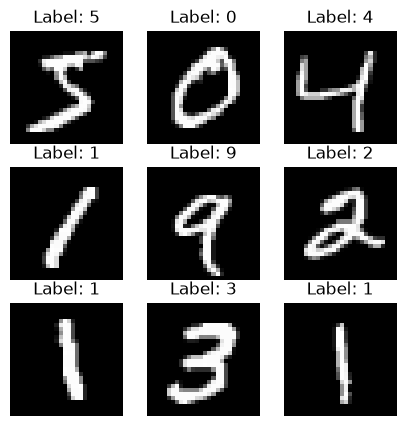

In [2]:
# Visual Inspection
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Task 1 (10 points)
1. Perform **upsampling** on the images to 32x32
2. Show the 5 sample of the result.


Hint: You need to store the result in an empty array. Replacing data to the  **X_test** cannot be done due to the shape of the array (10000, (28,28)). You need to create an array which match with the size of the new images.

In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

X_test_upsampled = np.empty((X_test.shape[0], 32, 32), dtype=np.float32)

for i in range(X_test.shape[0]):
    image = X_test[i]
    resized_image = tf.image.resize(image[..., np.newaxis],[32, 32], method='bilinear')
    X_test_upsampled[i] = resized_image.numpy().squeeze()

print("Original shape:", X_test.shape)
print("Upsampled shape:", X_test_upsampled.shape)

Original shape: (10000, 28, 28)
Upsampled shape: (10000, 32, 32)


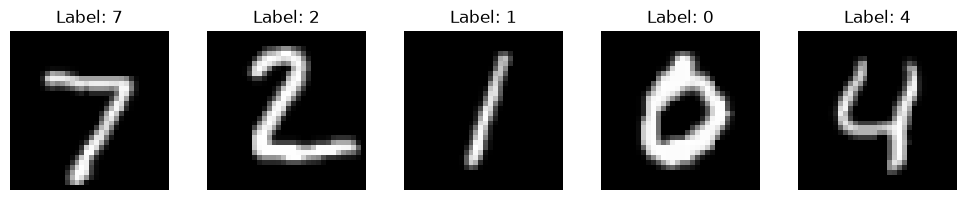

In [6]:
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
X_test_upsampled = np.empty((10000, 32, 32))

## Task 2 (10 points)
Perform normalization, so the pixel value will have a value in range of 0 until 1

In [9]:
X_test_normalized = X_test_upsampled / 255.0

print("Minimum pixel value:", X_test_normalized.min())
print("Maximum pixel value:", X_test_normalized.max())

Minimum pixel value: 0.0
Maximum pixel value: 0.0


In [10]:
X_test_upsampled / 255.0


array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

## Task 3 (10 points)
Transform / reshape the images into 1 dimensional array. Do it to the all images (after resizing and normalization).

Hint: You may need an empty array to store the result

In [11]:
X_test_flattened = np.empty((X_test_normalized.shape[0], 32 * 32), dtype=np.float32)

for i in range(X_test_normalized.shape[0]):
    X_test_flattened[i] = X_test_normalized[i].reshape(-1)

print("Before reshaping:", X_test_normalized.shape)
print("After reshaping:", X_test_flattened.shape)

Before reshaping: (10000, 32, 32)
After reshaping: (10000, 1024)
